In [1]:
import numpy as np
import pandas as pd
from pandas import Series, DataFrame

df = pd.read_csv('../../data/train.csv')
df

,id,LoanNr_ChkDgt,Name,City,State,Bank,BankState,ApprovalDate,ApprovalFY,NoEmp,...,CreateJob,RetainedJob,FranchiseCode,UrbanRural,RevLineCr,LowDoc,DisbursementDate,DisbursementGross,BalanceGross,Accept
0,64afe857c28,9448323000,MIDWEST CRANKSHAFT & ENGINE,HARVEY,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,9-Aug-96,1996,28,...,0,0,1,0,N,N,31-Mar-97,"$600,000.00",$0.00,0
1,1705a7346c2,2854405007,"Iredesign, Limited",CHICAGO,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,10-Dec-07,2008,1,...,1,1,0,1,N,N,31-Dec-07,"$25,400.00",$0.00,1
2,7439801ad8a,9300423010,PHILLY'S INC.,ROCHELLE,IL,BMO HARRIS BK NATL ASSOC,IL,23-May-96,1996,6,...,0,0,1,0,N,Y,30-Sep-96,"$20,000.00",$0.00,1
3,a3f8f9d0611,4349265000,USA Laser Imaging Inc.,Loves park,IL,ALPINE BANK & TRUST CO.,IL,4-Nov-10,2011,5,...,0,5,0,1,N,N,1-Mar-11,"$75,000.00",$0.00,1
4,71e4f243b5d,2433905006,"Dan Morrell, Inc.",LISLE,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,3-May-07,2007,3,...,1,3,0,1,N,N,31-May-07,"$50,000.00",$0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20763,530b1abc4d5,5400325006,OMC Construction & Restoration,MORTON GROVE,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,7-Sep-12,2012,1,...,10,0,0,1,Y,N,7-Sep-12,"$45,000.00",$0.00,1
20764,d759e7e1aac,2242345001,Ronald J Wirth,ROMEOVILLE,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,26-Jan-07,2007,1,...,6,4,0,1,N,N,31-Jan-07,"$55,000.00",$0.00,1
20765,d902be78167,7805983010,CHICAGO GOURMET FOODS,ELMHURST,IL,FIFTH THIRD BANK,IL,16-Nov-94,1995,8,...,0,0,1,0,N,Y,31-Jan-95,"$100,000.00",$0.00,0
20766,76adcc08afc,8905864007,"ANNIE RIVER SOLUTIONS, INC",GLEN ELLYN,IL,U.S. BANK NATIONAL ASSOCIATION,OH,6-Jun-05,2005,1,...,1,2,1,1,Y,N,30-Jun-05,"$178,634.00",$0.00,1


Query: What is the ratio of Approved vs. Denied loans?
<br>If 90% are accepted, the bank is aggressive. If 50% are denied, the bank is very conservative

        count  ratio_%
Accept                
1       16019    77.13
0        4749    22.87


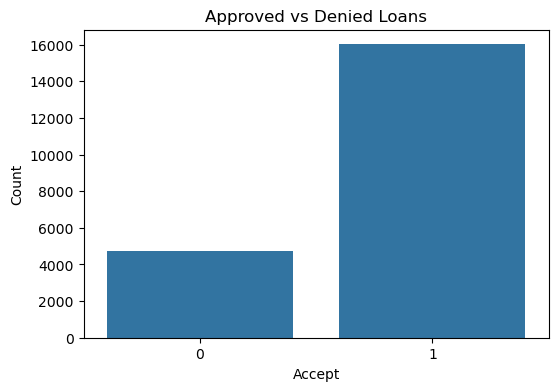

In [2]:
# What is the ratio of Approved vs. Denied loans?
import seaborn as sns
import matplotlib.pyplot as plt

counts = df['Accept'].value_counts(dropna=False)
ratios = df['Accept'].value_counts(normalize=True, dropna=False).mul(100).round(2)

summary = pd.DataFrame({'count': counts, 'ratio_%': ratios})
print(summary)

plt.figure(figsize=(6, 4))
sns.countplot(x='Accept', data=df)
plt.title('Approved vs Denied Loans')
plt.xlabel('Accept')
plt.ylabel('Count')
plt.show()

How does business maturity (NewExist) affect the outcome?
<br>Does being a "New Business" double the risk of denial? If so, Company X needs a higher score elsewhere to balance
     it out.

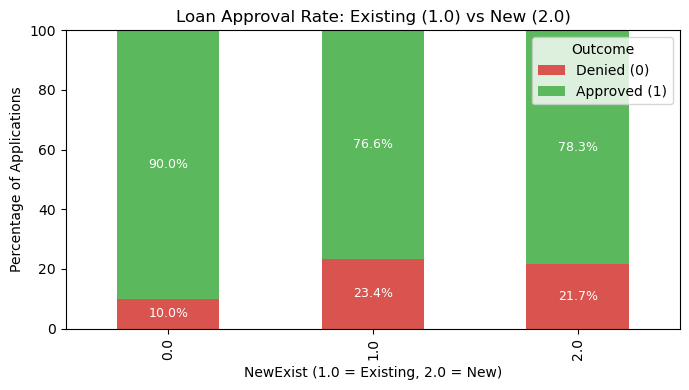

Accept,0,1
NewExist,,
0.0,10.000000,90.000000
1.0,23.416561,76.583439
2.0,21.712027,78.287973


In [3]:
# How does business maturity (NewExist) affect the outcome?
maturity_risk = (
    pd.crosstab(df['NewExist'], df['Accept'], normalize='index')
    .reindex(columns=[0, 1], fill_value=0)
    * 100
)

ax = maturity_risk.plot(
    kind='bar',
    stacked=True,
    color=['#d9534f', '#5cb85c'],
    figsize=(7, 4)
 )
ax.set_title('Loan Approval Rate: Existing (1.0) vs New (2.0)')
ax.set_xlabel('NewExist (1.0 = Existing, 2.0 = New)')
ax.set_ylabel('Percentage of Applications')
ax.set_ylim(0, 100)
ax.legend(['Denied (0)', 'Approved (1)'], title='Outcome', loc='upper right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', color='white', fontsize=9)

plt.tight_layout()
plt.show()

maturity_risk

In [6]:
# Quick check: what is NewExist = 0.0?
newexist_counts = df['NewExist'].value_counts(dropna=False).sort_index()
newexist_pct = (df['NewExist'].value_counts(dropna=False, normalize=True).sort_index() * 100).round(2)

newexist_summary = pd.DataFrame({
    'count': newexist_counts,
    'percentage_%': newexist_pct
})

print('NewExist value counts and percentages:')
display(newexist_summary)

print('\nNewExist vs Accept crosstab:')
display(pd.crosstab(df['NewExist'], df['Accept']))

NewExist value counts and percentages:


,count,percentage_%
NewExist,,
0.0,10,0.05
1.0,14178,68.27
2.0,6577,31.67
NaN,3,0.01



NewExist vs Accept crosstab:


Accept,0,1
NewExist,,
0.0,1,9
1.0,3320,10858
2.0,1428,5149


Loan Size vs. Risk (The "Skin in the Game")
<br>Is there a "Danger Zone" for loan amounts?
<br>Use log scale because loan sizes vary from $5k to $5M
Are very small loans (e.g., <$10k) denied more often (perhaps not worth the paperwork)? Or are massive loans (>$1M) the ones failing?

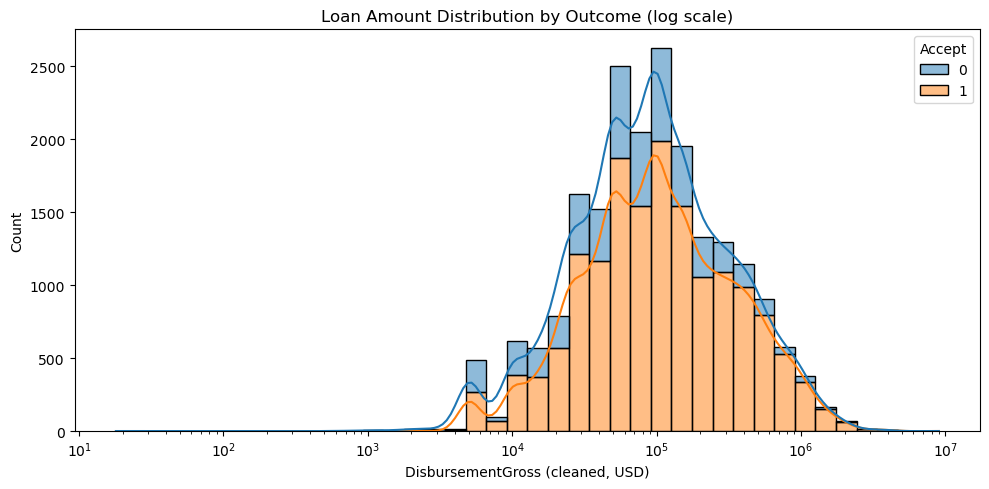

Top loan bands by denial rate:


,loan_band,applications,approval_rate,denial_rate
0,"(17.999, 20000.0]",2322,0.622308,0.377692
1,"(20000.0, 32886.8]",1832,0.740175,0.259825
2,"(50000.0, 66415.6]",1316,0.752280,0.247720
3,"(66415.6, 92964.0]",2077,0.753009,0.246991
4,"(92964.0, 116260.0]",2076,0.757707,0.242293


In [2]:
# Loan Size vs Risk: identify possible "danger zones" by loan amount
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Clean currency strings like "$123,456.00" into numeric values
df['DisbursementGross_cleaned'] = (
    df['DisbursementGross']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .replace({'': np.nan})
    .astype(float)
)

# Keep only rows with valid loan amount and outcome
plot_df = df.dropna(subset=['DisbursementGross_cleaned', 'Accept']).copy()
plot_df = plot_df[plot_df['DisbursementGross_cleaned'] > 0]

plt.figure(figsize=(10, 5))
sns.histplot(
    data=plot_df,
    x='DisbursementGross_cleaned',
    hue='Accept',
    multiple='stack',
    kde=True,
    log_scale=True,
    bins=40
)
plt.title('Loan Amount Distribution by Outcome (log scale)')
plt.xlabel('DisbursementGross (cleaned, USD)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Optional: quantify denial risk by amount bands
risk_by_band = (
    plot_df.assign(loan_band=pd.qcut(plot_df['DisbursementGross_cleaned'], q=10, duplicates='drop'))
    .groupby('loan_band', observed=False)['Accept']
    .agg(applications='size', approval_rate='mean')
    .assign(denial_rate=lambda x: 1 - x['approval_rate'])
    .sort_values('denial_rate', ascending=False)
    .reset_index()
)

print('Top loan bands by denial rate:')
display(risk_by_band.head(5))

Highest denial band: <br>
[ 18 , 20000] with denial rate ≈ 37.8% 
(approval ≈ 62.2%).<br>
Next highest: 
[20000, 32886.8] with denial rate ≈ 26.0%.<br>
Most other higher bands are around ≈ 24% − 25%.

In [8]:
# Audit DisbursementGross values before filtering with dropna
raw_disb = df['DisbursementGross']
cleaned_str = (
    raw_disb.astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .replace({'': np.nan, 'nan': np.nan, 'None': np.nan})
)
cleaned_num = pd.to_numeric(cleaned_str, errors='coerce')

audit = pd.DataFrame({
    'DisbursementGross_raw': raw_disb,
    'DisbursementGross_cleaned_str': cleaned_str,
    'DisbursementGross_cleaned_num': cleaned_num,
    'Accept': df['Accept']
})

# Invalid for analysis means missing/non-numeric/non-positive loan amount
invalid_mask = audit['DisbursementGross_cleaned_num'].isna() | (audit['DisbursementGross_cleaned_num'] <= 0)
invalid_rows = audit.loc[invalid_mask].copy()

print(f"Total rows: {len(audit):,}")
print(f"Invalid DisbursementGross rows: {len(invalid_rows):,}")
print(f"Invalid share: {len(invalid_rows) / len(audit):.2%}")

print('\nBreakdown of invalid reasons:')
reason_counts = pd.Series({
    'missing_or_non_numeric': int(audit['DisbursementGross_cleaned_num'].isna().sum()),
    'non_positive_value': int((audit['DisbursementGross_cleaned_num'] <= 0).sum())
})
display(reason_counts.to_frame('count'))

print('\nSample invalid rows (up to 25):')
display(invalid_rows.head(25))

# If you want to inspect all invalid rows, uncomment:
# display(invalid_rows)

Total rows: 20,768
Invalid DisbursementGross rows: 1
Invalid share: 0.00%

Breakdown of invalid reasons:


,count
missing_or_non_numeric,0
non_positive_value,1



Sample invalid rows (up to 25):


,DisbursementGross_raw,DisbursementGross_cleaned_str,DisbursementGross_cleaned_num,Accept
11414,$0.00,0.00,0.0,0


The "Efficiency" Ratio (Employees per Dollar)
<br>Does a high loan amount relative to the number of employees signal risk?. Looking for "Outliers." A company with 1 employee (NoEmp) asking for $2,000,000 is a red flag.

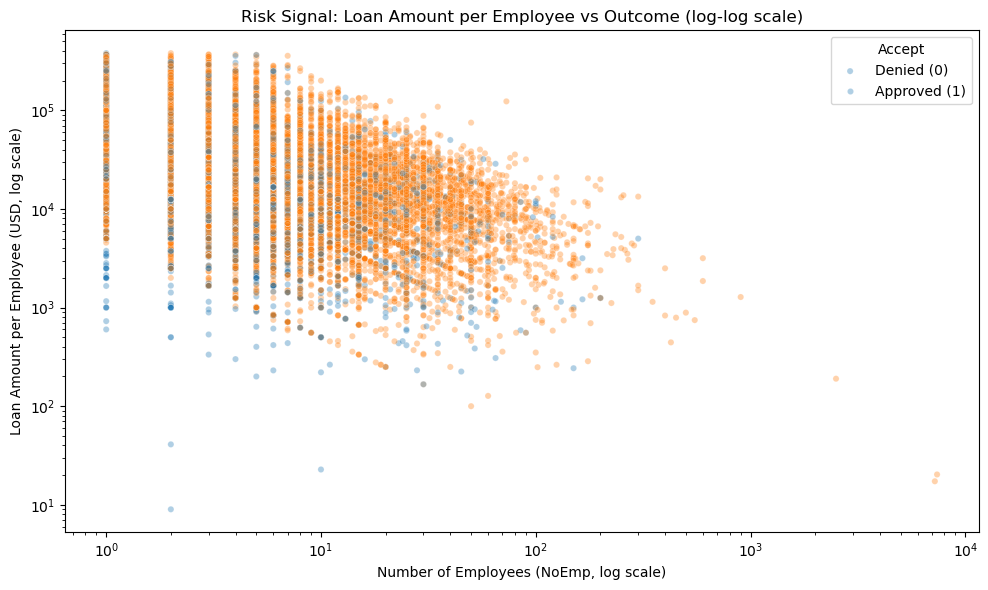

Top efficiency bands by denial rate:


,eff_band,applications,approval_rate,denial_rate
0,"(8.999, 4330.476]",2056,0.717899,0.282101
1,"(4330.476, 7500.0]",2187,0.734339,0.265661
2,"(20000.0, 25000.0]",1809,0.765616,0.234384
3,"(7500.0, 10700.2]",1924,0.776507,0.223493
4,"(85000.0, 3520000.0]",2039,0.781756,0.218244


Correlation(loan_per_employee, Accept): 0.0281 (negative means higher ratio -> lower approval)


In [10]:
# Does a high loan amount relative to number of employees signal risk?
# Build a stable metric: dollars requested per employee.
analysis_df = df.dropna(subset=['NoEmp', 'DisbursementGross_cleaned', 'Accept']).copy()
analysis_df = analysis_df[(analysis_df['NoEmp'] > 0) & (analysis_df['DisbursementGross_cleaned'] > 0)]

analysis_df['loan_per_employee'] = analysis_df['DisbursementGross_cleaned'] / analysis_df['NoEmp']

# Keep extreme outliers from dominating the chart while preserving most observations.
p99 = analysis_df['loan_per_employee'].quantile(0.99)
plot_df_eff = analysis_df[analysis_df['loan_per_employee'] <= p99].copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df_eff,
    x='NoEmp',
    y='loan_per_employee',
    hue='Accept',
    alpha=0.35,
    s=20
)
plt.xscale('log')
plt.yscale('log')
plt.title('Risk Signal: Loan Amount per Employee vs Outcome (log-log scale)')
plt.xlabel('Number of Employees (NoEmp, log scale)')
plt.ylabel('Loan Amount per Employee (USD, log scale)')
plt.legend(title='Accept', labels=['Denied (0)', 'Approved (1)'])
plt.tight_layout()
plt.show()

# Quantify risk by loan-per-employee deciles (higher decile = larger amount per employee).
risk_by_eff_band = (
    analysis_df.assign(eff_band=pd.qcut(analysis_df['loan_per_employee'], q=10, duplicates='drop'))
    .groupby('eff_band', observed=False)['Accept']
    .agg(applications='size', approval_rate='mean')
    .assign(denial_rate=lambda x: 1 - x['approval_rate'])
    .sort_values('denial_rate', ascending=False)
    .reset_index()
)

print('Top efficiency bands by denial rate:')
display(risk_by_eff_band.head(5))

# Correlation check (point-biserial equivalent through binary encoding).
corr = analysis_df[['loan_per_employee', 'Accept']].corr().iloc[0, 1]
print(f"Correlation(loan_per_employee, Accept): {corr:.4f} (negative means higher ratio -> lower approval)")

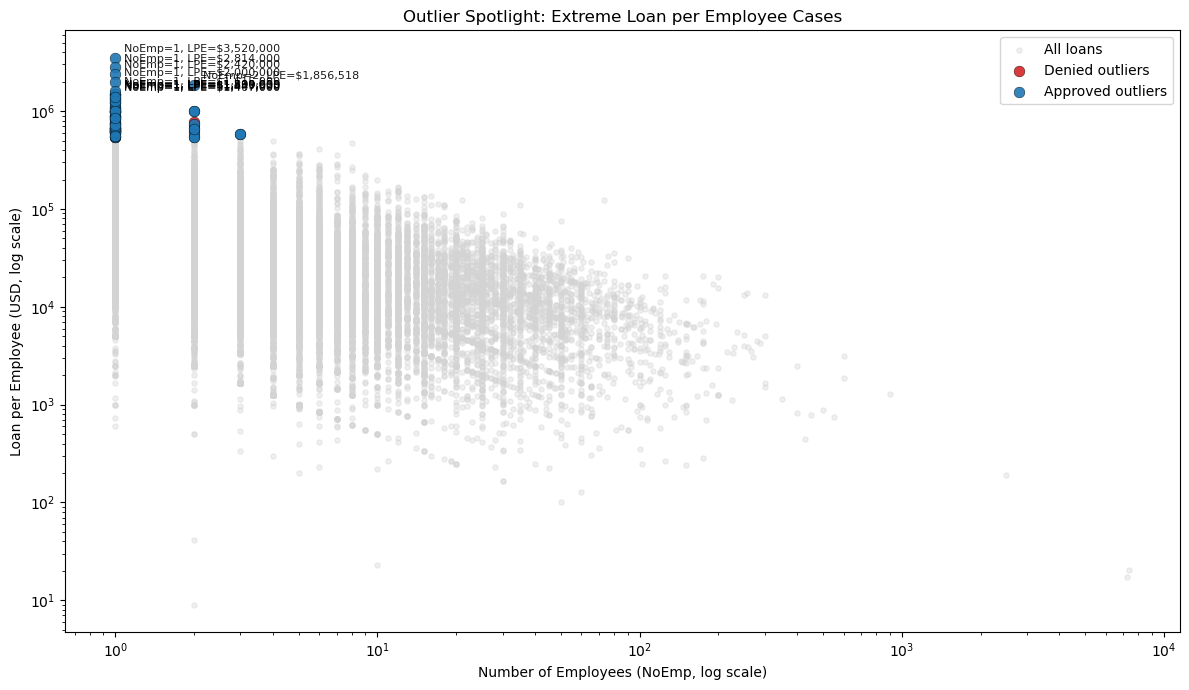

Outlier threshold (99.5th percentile): $550,000.00
Outliers shown: 107 of 20,555 rows (0.52%)


,NoEmp,DisbursementGross_cleaned,loan_per_employee,Accept
1587,1,3520000.0,3520000.0,1
5240,1,2814000.0,2814000.0,1
11332,1,2420000.0,2420000.0,1
14332,1,2000000.0,2000000.0,1
2642,2,3713037.0,1856518.5,1
16868,1,1615000.0,1615000.0,1
6432,1,1500000.0,1500000.0,1
11269,1,1500000.0,1500000.0,1
10736,1,1499000.0,1499000.0,1
3806,1,1479925.0,1479925.0,1


In [11]:
# Outlier spotlight: keep all points and make extreme loan-per-employee cases pop out
outlier_df = df.dropna(subset=['NoEmp', 'DisbursementGross_cleaned', 'Accept']).copy()
outlier_df = outlier_df[(outlier_df['NoEmp'] > 0) & (outlier_df['DisbursementGross_cleaned'] > 0)]
outlier_df['loan_per_employee'] = outlier_df['DisbursementGross_cleaned'] / outlier_df['NoEmp']

# Define outliers using a very high percentile so only the most extreme cases are highlighted
p995 = outlier_df['loan_per_employee'].quantile(0.995)
outliers = outlier_df[outlier_df['loan_per_employee'] >= p995].copy()

top_n = 12
top_outliers = outliers.nlargest(top_n, 'loan_per_employee').copy()

plt.figure(figsize=(12, 7))

# Background: all observations
plt.scatter(
    outlier_df['NoEmp'],
    outlier_df['loan_per_employee'],
    c='lightgray',
    alpha=0.35,
    s=14,
    label='All loans'
)

# Foreground: extreme outliers
palette = {0: '#d62728', 1: '#1f77b4'}
for val, label in [(0, 'Denied outliers'), (1, 'Approved outliers')]:
    d = outliers[outliers['Accept'] == val]
    if len(d) > 0:
        plt.scatter(
            d['NoEmp'],
            d['loan_per_employee'],
            c=palette[val],
            alpha=0.9,
            s=60,
            edgecolors='black',
            linewidths=0.3,
            label=label
        )

# Label the most extreme points so they are easy to inspect
for _, r in top_outliers.iterrows():
    plt.annotate(
        f"NoEmp={int(r['NoEmp'])}, LPE=${r['loan_per_employee']:,.0f}",
        (r['NoEmp'], r['loan_per_employee']),
        xytext=(6, 4),
        textcoords='offset points',
        fontsize=8,
        alpha=0.9
    )

plt.xscale('log')
plt.yscale('log')
plt.title('Outlier Spotlight: Extreme Loan per Employee Cases')
plt.xlabel('Number of Employees (NoEmp, log scale)')
plt.ylabel('Loan per Employee (USD, log scale)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Outlier threshold (99.5th percentile): ${p995:,.2f}")
print(f"Outliers shown: {len(outliers):,} of {len(outlier_df):,} rows ({len(outliers)/len(outlier_df):.2%})")

display(top_outliers[['NoEmp', 'DisbursementGross_cleaned', 'loan_per_employee', 'Accept']].head(top_n))

In [4]:
# NoEmp audit: counts, percentages, missing values, and invalid values
noemp_raw = df['NoEmp']

# Convert to numeric safely to catch unexpected text values as invalid
noemp_num = pd.to_numeric(noemp_raw, errors='coerce')

total_rows = len(noemp_raw)
missing_mask = noemp_raw.isna()
non_numeric_mask = noemp_raw.notna() & noemp_num.isna()
non_positive_mask = noemp_num.notna() & (noemp_num <= 0)
invalid_mask_noemp = missing_mask | non_numeric_mask | non_positive_mask

# Summary counts and percentages
summary_noemp = pd.DataFrame({
    'count': [
        total_rows,
        int(missing_mask.sum()),
        int(non_numeric_mask.sum()),
        int(non_positive_mask.sum()),
        int(invalid_mask_noemp.sum()),
        int((~invalid_mask_noemp).sum())
    ]
}, index=[
    'total_rows',
    'missing',
    'non_numeric',
    'non_positive (<=0)',
    'invalid_total',
    'valid_rows'
])
summary_noemp['percentage_%'] = (summary_noemp['count'] / total_rows * 100).round(2)

print('NoEmp data quality summary:')
display(summary_noemp)

# Value distribution for valid numeric values (top 20 most common)
valid_noemp = noemp_num[~invalid_mask_noemp]
value_counts = valid_noemp.value_counts(dropna=False).sort_values(ascending=False)
value_percent = (value_counts / total_rows * 100).round(2)
noemp_distribution = pd.DataFrame({
    'NoEmp': value_counts.index,
    'count': value_counts.values,
    'percentage_of_total_%': value_percent.values
})

print('\nTop 20 most frequent NoEmp values (valid only):')
display(noemp_distribution.head(20))

# Additional descriptive stats for valid values
print('\nDescriptive stats for valid NoEmp values:')
display(valid_noemp.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame('NoEmp'))

# Show sample invalid rows for inspection
invalid_noemp_rows = df.loc[invalid_mask_noemp, ['NoEmp', 'Accept']].copy()
print('\nSample invalid NoEmp rows (up to 20):')
display(invalid_noemp_rows.head(20))

NoEmp data quality summary:


,count,percentage_%
total_rows,20768,100.00
missing,0,0.00
non_numeric,0,0.00
non_positive (<=0),212,1.02
invalid_total,212,1.02
valid_rows,20556,98.98



Top 20 most frequent NoEmp values (valid only):


,NoEmp,count,percentage_of_total_%
0,1,3460,16.66
1,2,3320,15.99
2,3,2206,10.62
3,4,1840,8.86
4,5,1462,7.04
5,6,1052,5.07
6,10,753,3.63
7,8,710,3.42
8,7,672,3.24
9,12,473,2.28



Descriptive stats for valid NoEmp values:


,NoEmp
count,20556.000000
mean,10.895408
std,77.045620
min,1.000000
1%,1.000000
5%,1.000000
25%,2.000000
50%,4.000000
75%,10.000000
95%,38.000000



Sample invalid NoEmp rows (up to 20):


,NoEmp,Accept
70,0,1
160,0,1
239,0,1
260,0,0
358,0,1
394,0,1
414,0,1
586,0,1
740,0,0
796,0,1


Approval/Denial by NoEmp bands:


,NoEmp_band,applications,share_of_total_%,approval_rate_%,denial_rate_%
0,1,3460,16.83,70.87,29.13
1,2-5,8828,42.95,73.83,26.17
2,6-10,3553,17.28,78.41,21.59
3,11-50,4132,20.10,86.30,13.70
4,>50,583,2.84,91.77,8.23


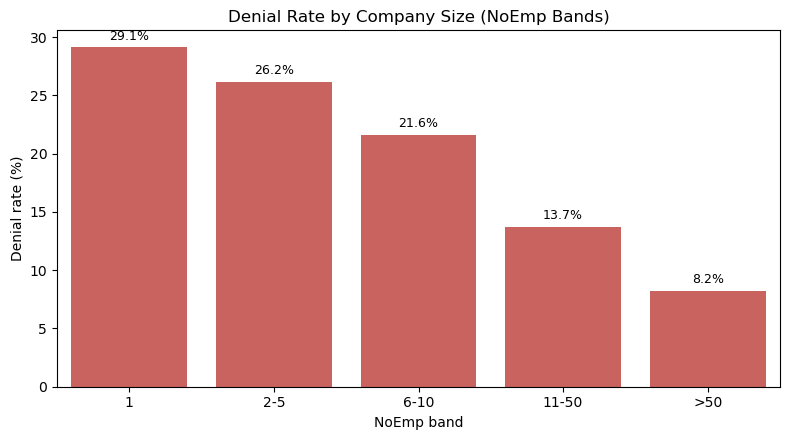

Highest denial band: 1 (29.13%) | Lowest denial band: >50 (8.23%)


In [5]:
# Approval rate by NoEmp bands: (1), (2-5), (6-10), (11-50), (>50)
noemp_band_df = df[['NoEmp', 'Accept']].copy()
noemp_band_df['NoEmp_num'] = pd.to_numeric(noemp_band_df['NoEmp'], errors='coerce')

# Keep only valid rows for this analysis
noemp_band_df = noemp_band_df[
    noemp_band_df['NoEmp_num'].notna()
    & (noemp_band_df['NoEmp_num'] > 0)
    & noemp_band_df['Accept'].notna()
].copy()

bins = [0, 1, 5, 10, 50, np.inf]
labels = ['1', '2-5', '6-10', '11-50', '>50']
noemp_band_df['NoEmp_band'] = pd.cut(noemp_band_df['NoEmp_num'], bins=bins, labels=labels, right=True)

band_summary = (
    noemp_band_df
    .groupby('NoEmp_band', observed=False)['Accept']
    .agg(applications='size', approval_rate='mean')
    .assign(denial_rate=lambda x: 1 - x['approval_rate'])
    .reset_index()
)

band_summary['approval_rate_%'] = (band_summary['approval_rate'] * 100).round(2)
band_summary['denial_rate_%'] = (band_summary['denial_rate'] * 100).round(2)
band_summary['share_of_total_%'] = (band_summary['applications'] / band_summary['applications'].sum() * 100).round(2)

print('Approval/Denial by NoEmp bands:')
display(band_summary[['NoEmp_band', 'applications', 'share_of_total_%', 'approval_rate_%', 'denial_rate_%']])

plt.figure(figsize=(8, 4.5))
ax = sns.barplot(data=band_summary, x='NoEmp_band', y='denial_rate_%', color='#d9534f')
ax.set_title('Denial Rate by Company Size (NoEmp Bands)')
ax.set_xlabel('NoEmp band')
ax.set_ylabel('Denial rate (%)')

for i, v in enumerate(band_summary['denial_rate_%']):
    ax.text(i, v + 0.4, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Simple risk signal note
highest_risk = band_summary.sort_values('denial_rate_%', ascending=False).iloc[0]
lowest_risk = band_summary.sort_values('denial_rate_%', ascending=True).iloc[0]
print(
    f"Highest denial band: {highest_risk['NoEmp_band']} ({highest_risk['denial_rate_%']:.2f}%) | "
    f"Lowest denial band: {lowest_risk['NoEmp_band']} ({lowest_risk['denial_rate_%']:.2f}%)"
)

Categorical Risk Heatmap (LowDoc & RevLineCr)
<br>Do specific loan "programs" have higher success rates?
<br>If LowDoc = Y has a 95% approval rate, but LowDoc = N has 60%, the program itself is a huge predictor, regardless of the company's financials.

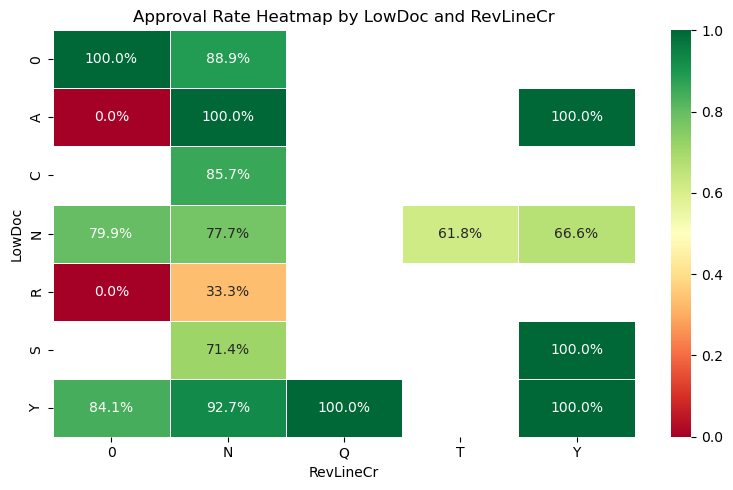

Approval rates table (%):


RevLineCr,0,N,Q,T,Y
LowDoc,,,,,
0,100.00,88.89,NaN,NaN,NaN
A,0.00,100.00,NaN,NaN,100.00
C,NaN,85.71,NaN,NaN,NaN
N,79.95,77.68,NaN,61.79,66.58
R,0.00,33.33,NaN,NaN,NaN
S,NaN,71.43,NaN,NaN,100.00
Y,84.07,92.74,100.0,NaN,100.00


In [6]:
# Approval rate by loan "program" dimensions: LowDoc x RevLineCr
analysis_cols = ['LowDoc', 'RevLineCr', 'Accept']
program_df = df[analysis_cols].dropna().copy()

# Normalize category text to avoid duplicate buckets caused by casing/spaces
program_df['LowDoc'] = program_df['LowDoc'].astype(str).str.strip().str.upper()
program_df['RevLineCr'] = program_df['RevLineCr'].astype(str).str.strip().str.upper()

pivot = program_df.pivot_table(
    index='LowDoc',
    columns='RevLineCr',
    values='Accept',
    aggfunc='mean'
).sort_index().sort_index(axis=1)

plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.1%',
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor='white'
 )
plt.title('Approval Rate Heatmap by LowDoc and RevLineCr')
plt.xlabel('RevLineCr')
plt.ylabel('LowDoc')
plt.tight_layout()
plt.show()

print('Approval rates table (%):')
display((pivot * 100).round(2))

In [7]:
# LowDoc audit: counts, percentages, missing values, and invalid categories
lowdoc_raw = df['LowDoc']

# Standardize to string for consistent category checks
lowdoc_std = lowdoc_raw.astype('string').str.strip().str.upper()

# Missing includes true NaN and blank strings
missing_mask_lowdoc = lowdoc_raw.isna() | lowdoc_std.isna() | (lowdoc_std == '')

# Canonical valid labels for this flag
valid_values = {'Y', 'N'}
valid_mask_lowdoc = lowdoc_std.isin(valid_values)
invalid_mask_lowdoc = (~missing_mask_lowdoc) & (~valid_mask_lowdoc)

total_rows = len(df)
summary_lowdoc = pd.DataFrame(
    {'count': [
        total_rows,
        int(missing_mask_lowdoc.sum()),
        int(invalid_mask_lowdoc.sum()),
        int(valid_mask_lowdoc.sum())
    ]},
    index=['total_rows', 'missing', 'invalid_non_YN', 'valid_YN']
)
summary_lowdoc['percentage_%'] = (summary_lowdoc['count'] / total_rows * 100).round(2)

print('LowDoc data quality summary:')
display(summary_lowdoc)

# Full distribution (including missing shown as MISSING)
lowdoc_distribution = (
    lowdoc_std.fillna('MISSING')
    .replace({'': 'MISSING'})
    .value_counts(dropna=False)
    .rename_axis('LowDoc_value')
    .to_frame('count')
)
lowdoc_distribution['percentage_%'] = (lowdoc_distribution['count'] / total_rows * 100).round(2)

print('\nLowDoc value distribution (all categories):')
display(lowdoc_distribution)

print('\nSample invalid LowDoc rows (up to 20):')
display(df.loc[invalid_mask_lowdoc, ['LowDoc', 'RevLineCr', 'Accept']].head(20))

LowDoc data quality summary:


,count,percentage_%
total_rows,20768,100.00
missing,36,0.17
invalid_non_YN,51,0.25
valid_YN,20681,99.58



LowDoc value distribution (all categories):


,count,percentage_%
LowDoc_value,,
N,16903,81.39
Y,3778,18.19
MISSING,36,0.17
0,26,0.13
S,8,0.04
C,7,0.03
A,6,0.03
R,4,0.02



Sample invalid LowDoc rows (up to 20):


,LowDoc,RevLineCr,Accept
56,S,N,1
394,S,N,1
412,0,NaN,1
1413,R,N,0
1949,0,NaN,1
1959,S,N,1
2225,C,N,1
2555,0,N,1
2994,0,N,1
3779,A,Y,1


In [8]:
# RevLineCr audit: counts, percentages, missing values, and invalid categories
revline_raw = df['RevLineCr']

# Standardize to string for consistent category checks
revline_std = revline_raw.astype('string').str.strip().str.upper()

# Missing includes true NaN and blank strings
missing_mask_revline = revline_raw.isna() | revline_std.isna() | (revline_std == '')

# Canonical valid labels for this flag
valid_values_revline = {'Y', 'N'}
valid_mask_revline = revline_std.isin(valid_values_revline)
invalid_mask_revline = (~missing_mask_revline) & (~valid_mask_revline)

total_rows = len(df)
summary_revline = pd.DataFrame(
    {'count': [
        total_rows,
        int(missing_mask_revline.sum()),
        int(invalid_mask_revline.sum()),
        int(valid_mask_revline.sum())
    ]},
    index=['total_rows', 'missing', 'invalid_non_YN', 'valid_YN']
)
summary_revline['percentage_%'] = (summary_revline['count'] / total_rows * 100).round(2)

print('RevLineCr data quality summary:')
display(summary_revline)

# Full distribution (including missing shown as MISSING)
revline_distribution = (
    revline_std.fillna('MISSING')
    .replace({'': 'MISSING'})
    .value_counts(dropna=False)
    .rename_axis('RevLineCr_value')
    .to_frame('count')
)
revline_distribution['percentage_%'] = (revline_distribution['count'] / total_rows * 100).round(2)

print('\nRevLineCr value distribution (all categories):')
display(revline_distribution)

print('\nSample invalid RevLineCr rows (up to 20):')
display(df.loc[invalid_mask_revline, ['RevLineCr', 'LowDoc', 'Accept']].head(20))

RevLineCr data quality summary:


,count,percentage_%
total_rows,20768,100.00
missing,126,0.61
invalid_non_YN,5328,25.65
valid_YN,15314,73.74



RevLineCr value distribution (all categories):


,count,percentage_%
RevLineCr_value,,
N,10037,48.33
Y,5277,25.41
0,5046,24.3
T,281,1.35
MISSING,126,0.61
Q,1,0.0



Sample invalid RevLineCr rows (up to 20):


,RevLineCr,LowDoc,Accept
5,0,Y,0
9,0,N,1
11,0,N,1
13,0,N,1
16,0,N,1
17,0,N,1
24,0,Y,0
25,0,N,1
28,0,N,0
30,0,N,1


Bank column. Are there any banks that always approve loans?

How many "empty" banks have approved loans?